In [1]:
import numpy as np
import matplotlib.pyplot as plt
import python.Postproc_stc as stc
import python.helper_func as he
import scipy.constants as sc

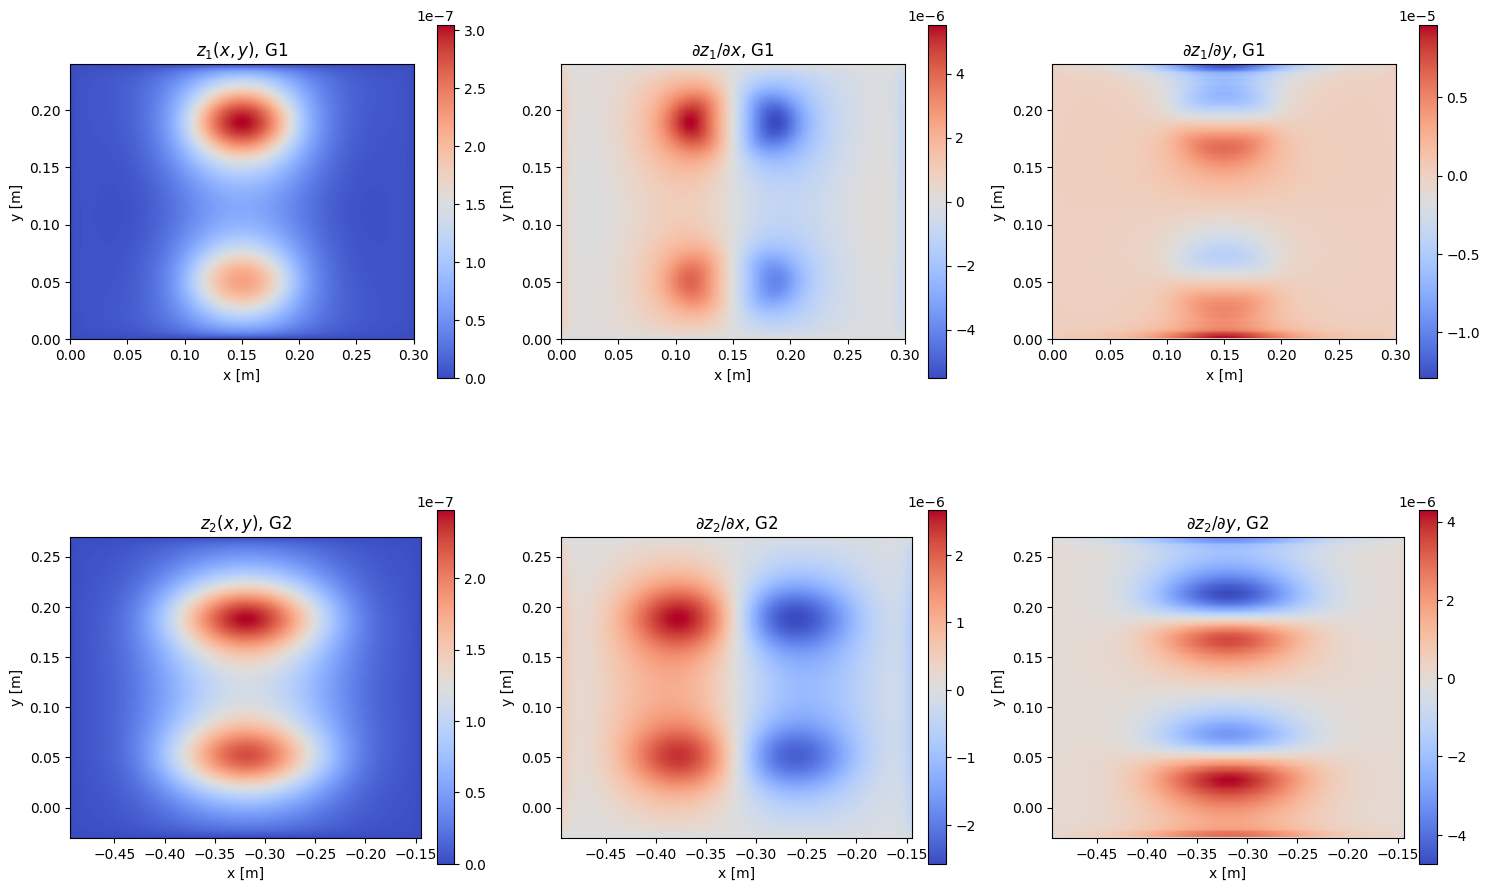

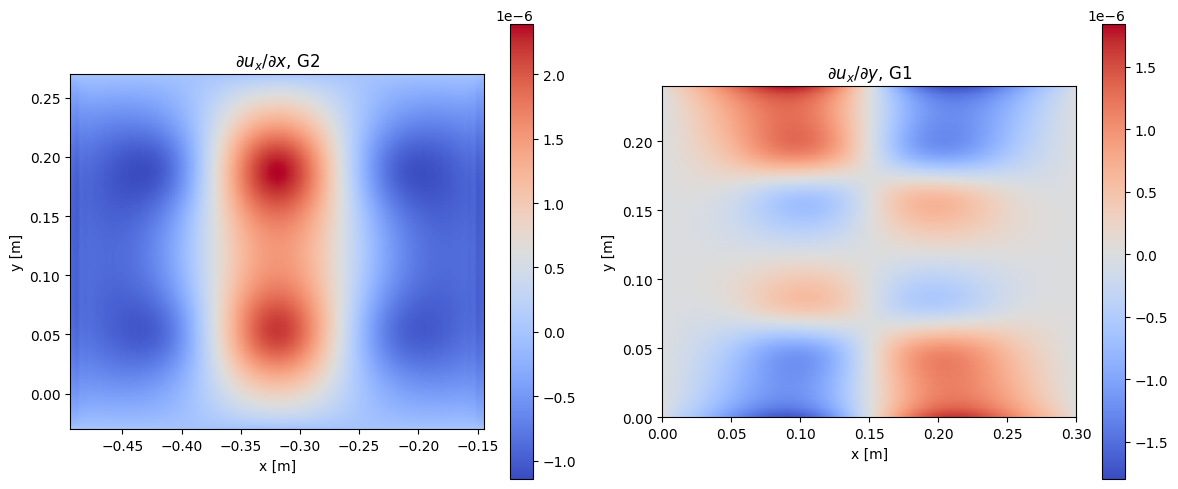

In [2]:
pos_ref, s2_ref = he.compute_roof_reference(
    lam_ref=810e-9,
    L=0.58,
    alpha_deg=56.0,
    x1_ref=0.15,
    y1_ref=0.05,
)

maps = he.load_comsol_grating_maps(
    vert_G1_file="./data/combined_data_vert_disp_reseau1_pitch.csv",
    vert_G2_file="./data/combined_data_vert_disp_reseau2_pitch.csv",
    hor_G1_file="./data/combined_data_hor_disp_reseau1_pitch.csv",
    hor_G2_file="./data/combined_data_hor_disp_reseau2_pitch.csv",
    pos_ref=pos_ref,
    slice_idx=35,#### 35 min of heating
    sigma=0.0,
    y0_G2=0.05,
)

# ============================================================
# Vertical deformation maps
# ============================================================

fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# -------------------------
# G1
# -------------------------
im0 = axs[0, 0].imshow(
    maps["z1_map"],
    origin="lower",
    extent=maps["extent1"],
    cmap="coolwarm"
)
axs[0, 0].set_title(r"$z_1(x,y)$, G1")
axs[0, 0].set_xlabel("x [m]")
axs[0, 0].set_ylabel("y [m]")
plt.colorbar(im0, ax=axs[0, 0], fraction=0.046, pad=0.06)


im1 = axs[0, 1].imshow(
    maps["dzx1_map"],
    origin="lower",
    extent=maps["extent1"],
    cmap="coolwarm"
)
axs[0, 1].set_title(r"$\partial z_1/\partial x$, G1")
axs[0, 1].set_xlabel("x [m]")
axs[0, 1].set_ylabel("y [m]")
plt.colorbar(im1, ax=axs[0, 1], fraction=0.046, pad=0.06)


im2 = axs[0, 2].imshow(
    maps["dzy1_map"],
    origin="lower",
    extent=maps["extent1"],
    cmap="coolwarm"
)
axs[0, 2].set_title(r"$\partial z_1/\partial y$, G1")
axs[0, 2].set_xlabel("x [m]")
axs[0, 2].set_ylabel("y [m]")
plt.colorbar(im2, ax=axs[0, 2], fraction=0.046, pad=0.06)


# -------------------------
# G2
# -------------------------
im3 = axs[1, 0].imshow(
    maps["z2_map"],
    origin="lower",
    extent=maps["extent2"],
    cmap="coolwarm"
)
axs[1, 0].set_title(r"$z_2(x,y)$, G2")
axs[1, 0].set_xlabel("x [m]")
axs[1, 0].set_ylabel("y [m]")
plt.colorbar(im3, ax=axs[1, 0], fraction=0.046, pad=0.04)


im4 = axs[1, 1].imshow(
    maps["dzx2_map"],
    origin="lower",
    extent=maps["extent2"],
    cmap="coolwarm"
)
axs[1, 1].set_title(r"$\partial z_2/\partial x$, G2")
axs[1, 1].set_xlabel("x [m]")
axs[1, 1].set_ylabel("y [m]")
plt.colorbar(im4, ax=axs[1, 1], fraction=0.046, pad=0.04)


im5 = axs[1, 2].imshow(
    maps["dzy2_map"],
    origin="lower",
    extent=maps["extent2"],
    cmap="coolwarm"
)
axs[1, 2].set_title(r"$\partial z_2/\partial y$, G2")
axs[1, 2].set_xlabel("x [m]")
axs[1, 2].set_ylabel("y [m]")
plt.colorbar(im5, ax=axs[1, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


# ============================================================
# Horizontal displacement derivatives
# ============================================================

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

im0 = axs[0].imshow(
    maps["dux2_map"],
    origin="lower",
    extent=maps["extent2"],
    cmap="coolwarm"
)
axs[0].set_title(r"$\partial u_x/\partial x$, G2")
axs[0].set_xlabel("x [m]")
axs[0].set_ylabel("y [m]")
plt.colorbar(im0, ax=axs[0])


im1 = axs[1].imshow(
    maps["duy2_map"],
    origin="lower",
    extent=maps["extent1"],
    cmap="coolwarm"
)
axs[1].set_title(r"$\partial u_x/\partial y$, G1")
axs[1].set_xlabel("x [m]")
axs[1].set_ylabel("y [m]")
plt.colorbar(im1, ax=axs[1])

plt.tight_layout()
plt.show()

In [3]:
opl = he.compute_compressor_opl(
    maps=maps,
    pos_ref=pos_ref,
    s2_ref=s2_ref,

    lam_min=780e-9,
    lam_max=836e-9,
    n_lam=120,

    d=1.0 / 1.8e6,
    L=0.58,
    alpha_deg=56.0,
    gamma_deg=0.0,
    
    x0=0.15,
    y0=0.05,
    wy=0.028,
    
    coeff=1.0,
    order=2,
    mask_threshold=5e-2,
    
    use_horizontal_displacement=True,
)

First compressor call: warming up Numba with one wavelength...
Numba warm-up complete.
Deformed compressor OPL: 2.81 s
Flat compressor OPL: 2.13 s


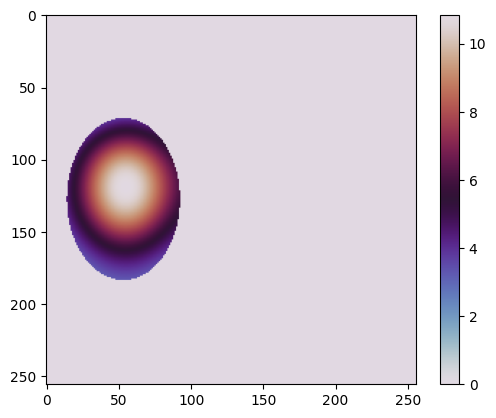

In [4]:
OPLstc    = opl["OPLstc"]
phi_g_stc = opl["phi_g_stc"]
OPL0      = opl["OPL0"]
phi_g_0   = opl["phi_g_0"]
lams=opl["lams"]
phi_omega=stc.get_phi(OPL0,phi_g_0,OPLstc,phi_g_stc,lams)
plt.imshow(phi_omega[:,:,60],cmap='twilight')
plt.colorbar()


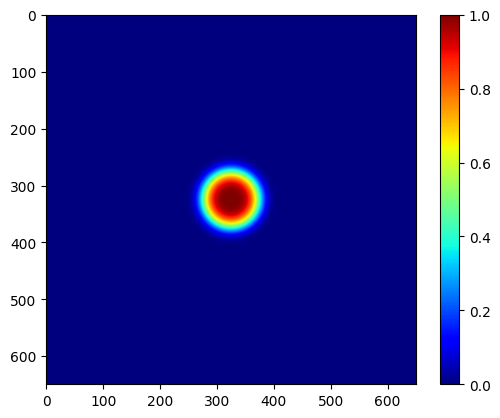

In [5]:
beam = he.prepare_output_beam(
    maps,
    alpha_deg=56.0,
    wx0=0.028,
    wy0=0.028,
    x0=0.15,
    y0=0.05,
    order=2,
    interp_size=0.35,
    interp_points=650,
)

plt.imshow(beam["Eout"], cmap="jet")
plt.colorbar()
plt.show()

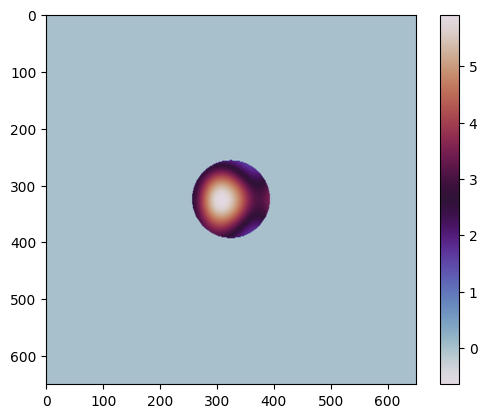

In [6]:
phase = he.prepare_phase_cube(
    phi_omega=phi_omega,
    maps=maps,
    beam=beam,
    alpha_deg=56.0,
    mask_threshold=3e-3,
)

omega_idx = 0

plt.imshow(
    phase["phi_omega_center"][:, :, omega_idx]
    * phase["mask"],
    cmap="twilight",
)
phi_omega_center=phase["phi_omega_center"]
plt.colorbar()
plt.show()

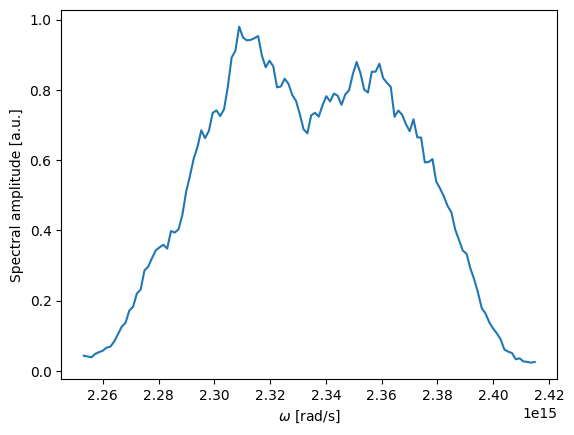

In [7]:
spectrum = he.prepare_measured_spectrum(
    spectrum_file="./data/Sortie_A3_2J.txt",
    lams=lams,
    row_start=1254,
    row_stop=1427,
)

plt.plot(
    spectrum["omega_uniform"],
    spectrum["spectrum_uniform"],
)
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel("Spectral amplitude [a.u.]")
plt.show()

# optional

Far-field FFT: using GPU (CuPy)
Backend                    : GPU (CuPy)
Real-space pixel size      : 5.393e-04 m
Focus-plane pixel size     : 1.675 µm


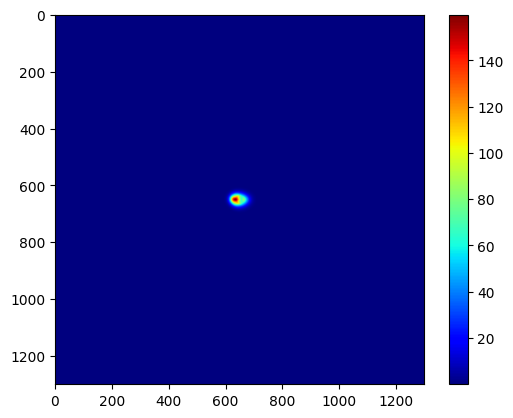

In [8]:
farfield = he.compute_far_field(
    Eout=beam["Eout"],
    phi_omega_center=phi_omega_center,
    spectrum_uniform=spectrum["spectrum_uniform"],
    pad_factor=2,
    lambda_focus=800e-9,
    focal_length=1.468,
    x_min=0.0,
    x_max=0.35,
)

E_ff_om = farfield["E_ff_om"]
dx_focus = farfield["dx_focus"]

plt.imshow(farfield["I_ff"], cmap="jet")
plt.colorbar()
plt.show()


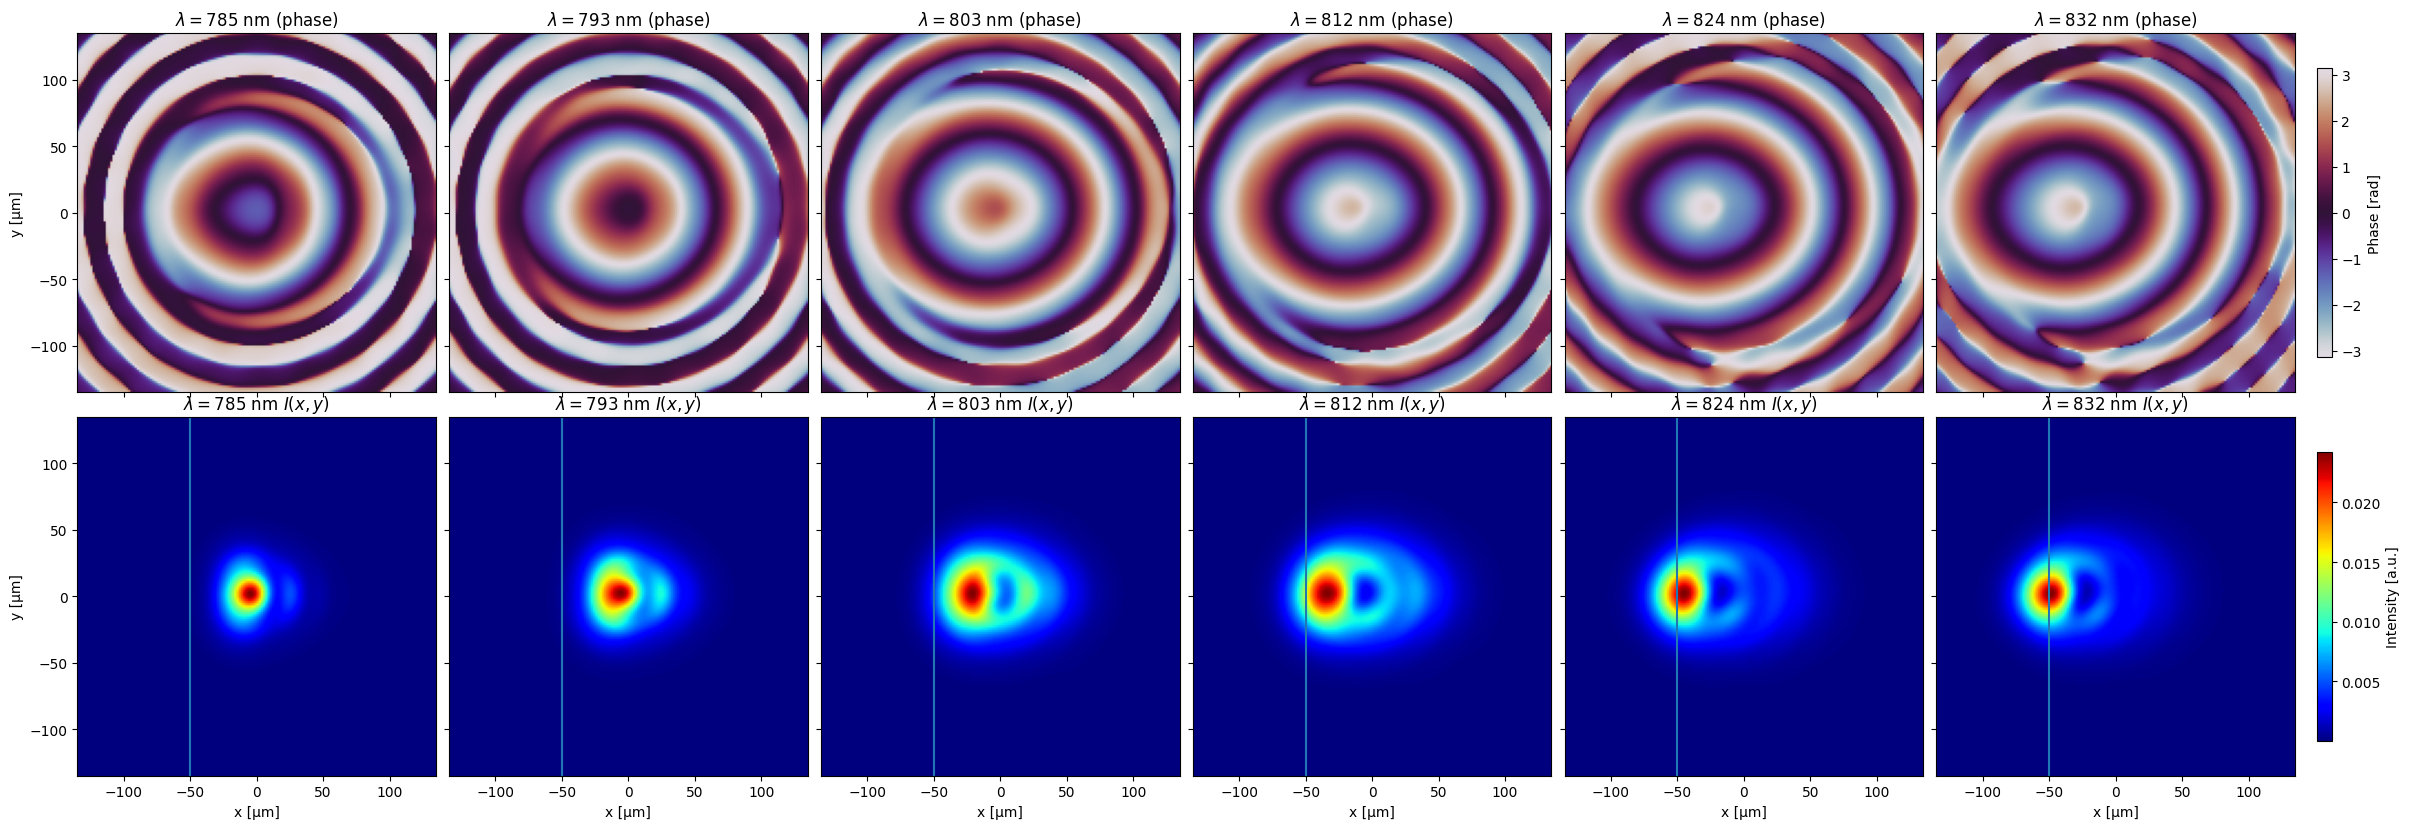

In [9]:
omegas = 2 * np.pi * sc.c / lams

fixed = he.prepare_fixed_wavelength_slices(
    E_ff_om=E_ff_om,
    omegas=omegas,
    dx_focus=dx_focus,
    wavelengths_nm=np.array([785, 793, 803, 812, 824, 832]),
    crop_size=162,
)

x_cropped = fixed["x_cropped"]
wavelengths_nm = fixed["wavelengths_nm"]
extent_xy = [x_cropped.min(), x_cropped.max(),
             x_cropped.min(), x_cropped.max()]

fig, axes = plt.subplots(2, 6, figsize=(24, 8), constrained_layout=True)

for i, lam_nm in enumerate(wavelengths_nm):
    im0 = axes[0, i].imshow(
        fixed["phase_slices"][i],
        cmap="twilight",
        extent=extent_xy,
        origin="lower",
    )
    axes[0, i].set_title(fr"$\lambda={lam_nm:g}$ nm (phase)")

    im1 = axes[1, i].imshow(
        fixed["intensity_slices"][i],
        cmap="jet",
        extent=extent_xy,
        origin="lower",
    )
    axes[1, i].set_title(fr"$\lambda={lam_nm:g}$ nm $I(x,y)$")
    axes[1, i].set_xlabel("x [µm]")
    axes[1, i].axvline(-50)

    if i == 0:
        axes[0, i].set_ylabel("y [µm]")
        axes[1, i].set_ylabel("y [µm]")

    axes[0, i].label_outer()
    axes[1, i].label_outer()

fig.colorbar(im0, ax=axes[0, :], location="right",
             shrink=0.8, pad=0.01, label="Phase [rad]")

fig.colorbar(im1, ax=axes[1, :], location="right",
             shrink=0.8, pad=0.01, label="Intensity [a.u.]")

# plt.savefig("FF_phase_amp_fixed_wavelengths_soutenance.png", dpi=300)
plt.show()

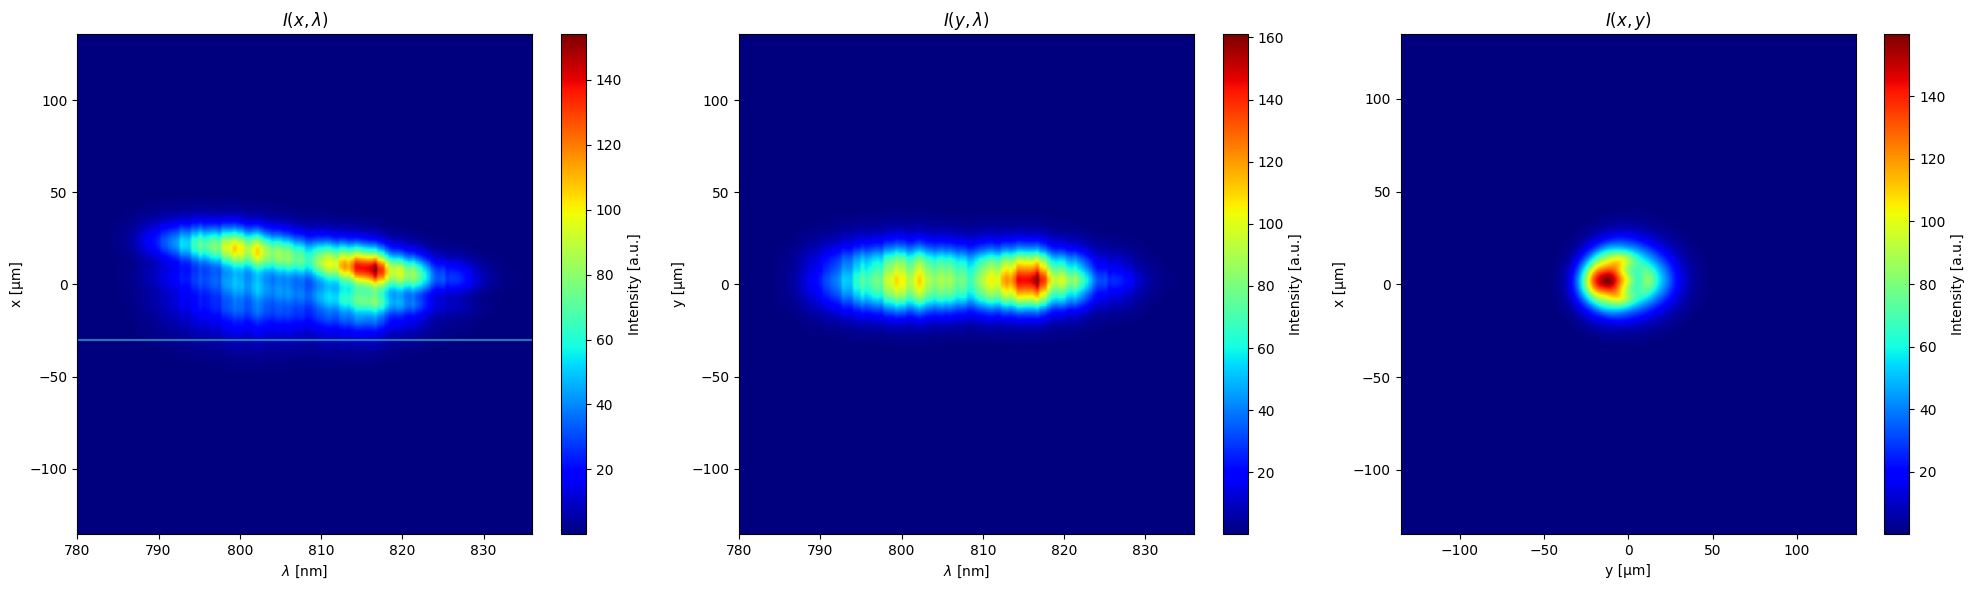

In [10]:
# ============================================================
# Spectral focal-plane maps
# ============================================================

ff_maps = he.prepare_far_field_spectral_maps(
    E_ff_om=E_ff_om,
    lams=lams,
    dx_focus=dx_focus,
    crop_factor=4,
)

plt.figure(figsize=(20, 6))

# I(x, λ)
plt.subplot(1, 3, 1)
plt.imshow(ff_maps["Iff_sorted1"], extent=ff_maps["extent_lambda"],
           cmap="jet", aspect="auto")
plt.xlabel(r"$\lambda$ [nm]")
plt.ylabel("x [µm]")
plt.title(r"$I(x,\lambda)$")
plt.axhline(-30)
plt.colorbar(label="Intensity [a.u.]")

# I(y, λ)
plt.subplot(1, 3, 2)
plt.imshow(ff_maps["Iff_sorted3"], extent=ff_maps["extent_lambda"],
           cmap="jet", aspect="auto", origin="lower")
plt.xlabel(r"$\lambda$ [nm]")
plt.ylabel("y [µm]")
plt.title(r"$I(y,\lambda)$")
plt.colorbar(label="Intensity [a.u.]")

# I(x, y)
plt.subplot(1, 3, 3)
plt.imshow(
    ff_maps["Iff2"],
    extent=[x_cropped.min(), x_cropped.max(),
            x_cropped.min(), x_cropped.max()],
    cmap="jet",
    aspect="auto",
    origin="lower",
)
plt.xlabel("y [µm]")
plt.ylabel("x [µm]")
plt.title(r"$I(x,y)$")
plt.colorbar(label="Intensity [a.u.]")

plt.tight_layout()
# plt.savefig("FF_Spectral_amp_and_amp_FIN.png", dpi=300)
plt.show()

Temporal FFT: using GPU (CuPy)
Backend: GPU (CuPy)


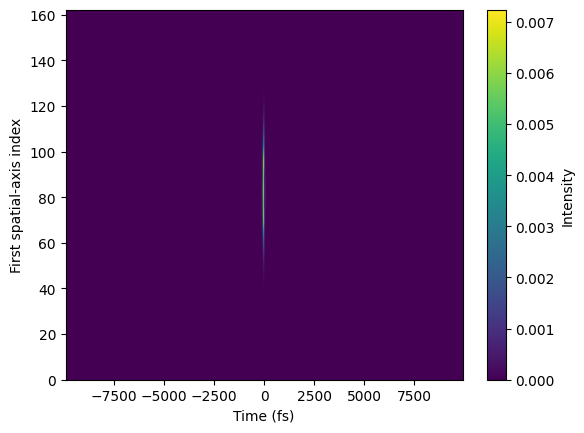

(162, 162, 136)


In [11]:
# ============================================================
# Spectral -> temporal focal field
# ============================================================
omegas = np.sort(2.0 * np.pi * sc.c / lams)
temporal = he.far_field_to_time(
    E_ff_om=E_ff_om,
    omegas=omegas,
    spatial_crop_factor=8,
    Nw_uniform=512,
    pad_factor=8,
    time_crop=30,
    use_gpu=True,

)

# ------------------------------------------------------------
# Diagnostic temporal slice
# ------------------------------------------------------------

plt.imshow(temporal["I_t"][:,temporal["Ny"] // 2,:],
    aspect="auto",
    origin="lower",
    extent=[temporal["t_axis"][0] * 1e15,temporal["t_axis"][-1] * 1e15,0,temporal["Nx"],],)
plt.xlabel("Time (fs)")
plt.ylabel("First spatial-axis index")
plt.colorbar(label="Intensity")
plt.show()
print(temporal["Itt"].shape)

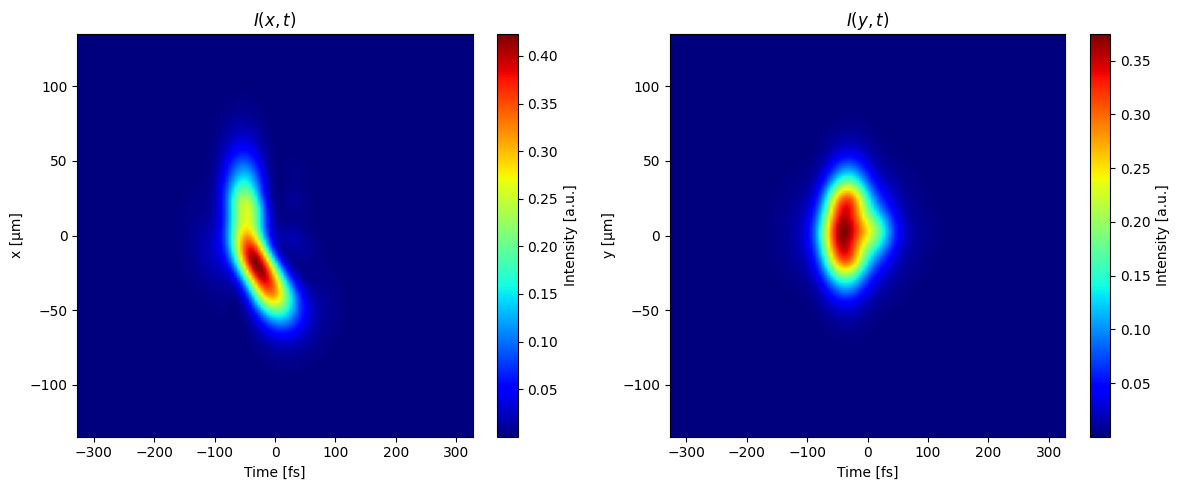

In [12]:
t_axis_new = temporal["t_axis_new"]
A, B = temporal["A"], temporal["B"]

extent_t = [
    t_axis_new[0] * 1e15,
    t_axis_new[-1] * 1e15,
    x_cropped.min(),
    x_cropped.max(),
]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(A, extent=extent_t, cmap="jet", aspect="auto", origin="lower")
plt.xlabel("Time [fs]")
plt.ylabel("x [µm]")
plt.title(r"$I(x,t)$")
plt.colorbar(label="Intensity [a.u.]")

plt.subplot(1, 2, 2)
plt.imshow(B, extent=extent_t, cmap="jet", aspect="auto", origin="lower")
plt.xlabel("Time [fs]")
plt.ylabel("y [µm]")
plt.title(r"$I(y,t)$")
plt.colorbar(label="Intensity [a.u.]")

plt.tight_layout()
# plt.savefig("Temporal_intensity_soutenance.png", dpi=300)
plt.show()

In [13]:
# Compute total intensity and phase
I_total_t,phase = temporal["total_t"], temporal["phase"]  # shape: (Nw_pad,)

# Plot with two y-axes
fig, ax1 = plt.subplots(figsize=(8,5))

# Left y-axis: total intensity
ax1.plot(t_axis_new*1e15, I_total_t, color='tab:blue', label='Total intensity')
ax1.set_xlabel('Time [fs]')
ax1.set_ylabel('Total intensity [a.u]', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Right y-axis: phase
ax2 = ax1.twinx()
ax2.plot(t_axis_new*1e15, phase, color='tab:red', label='Phase')
ax2.set_ylabel('Phase [rad]', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Optional: add title and grid
plt.title('Total temporal intensity and phase')
ax1.grid(True)

fig.tight_layout()
#plt.savefig("Total_temporal_intensity.png",dpi=300)
plt.show()


KeyError: 'total_t'